In [4]:
# Day 2 warm-up - recreate yesterday from memory
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create a small 5-farm dataset from memory
# Use Nigerian states and crops you remember
my_farms = {
    'state': ['Oyo', 'Kano', 'Benue', 'Enugu', 'Lagos'],
    'crop': ['Cassava', 'Maize', 'Yam', 'Rice', 'Cassava'],
    'yield_tons': [18.5, 12.3, 22.0, 16.8, 14.2],
    'rainfall_mm': [1200, 650, 1100, 1350, 1500]
}

df = pd.DataFrame(my_farms)

print("✅ Day 2 warm-up complete!")
print(f"Farms in dataset: {df['state'].tolist()}")
print(f"States covered: {df['state'].tolist()}")
print(f"Average yield: {df['yield_tons'].mean():.1f} tons")


✅ Day 2 warm-up complete!
Farms in dataset: ['Oyo', 'Kano', 'Benue', 'Enugu', 'Lagos']
States covered: ['Oyo', 'Kano', 'Benue', 'Enugu', 'Lagos']
Average yield: 16.8 tons


In [5]:
# Cell 2 - Bigger and more realistic farm dataset

import pandas as pd
import numpy as np

# Set random seed so results are consistent
np.random.seed(42)

# Nigerian states
states = [
    'Oyo', 'Kano', 'Benue', 'Enugu', 'Lagos',
    'Ondo', 'Kaduna', 'Rivers', 'Niger', 'Imo',
    'Kebbi', 'Taraba', 'Plateau', 'Kwara', 'Nasarawa'
]

# Crops common in Nigeria
crops = ['Cassava', 'Maize', 'Yam', 'Rice', 'Cocoa', 'Groundnut']

# Create 50 farm records
n_farms = 50

farms_df = pd.DataFrame({
    'farm_id': range(1, n_farms + 1),
    'state': np.random.choice(states, n_farms),
    'crop': np.random.choice(crops, n_farms),
    'farm_size_ha': np.round(np.random.uniform(0.5, 15.0, n_farms), 1),
    'yield_tons': np.round(np.random.uniform(5.0, 30.0, n_farms), 1),
    'rainfall_mm': np.random.randint(500, 2200, n_farms),
    'soil_ph': np.round(np.random.uniform(5.0, 7.5, n_farms), 1),
    'fertilizer_kg': np.random.randint(0, 200, n_farms),
    'improved_seeds': np.random.choice([True, False], n_farms),
    'irrigation': np.random.choice([True, False], n_farms, p=[0.3, 0.7]),
    'year': np.random.choice([2022, 2023, 2024], n_farms),
    'income_naira': np.random.randint(200000, 2000000, n_farms)
})

# Introduce some missing data (this is REAL life — data is never perfect)
farms_df.loc[5, 'soil_ph'] = None
farms_df.loc[12, 'rainfall_mm'] = None
farms_df.loc[23, 'income_naira'] = None
farms_df.loc[37, 'fertilizer_kg'] = None

print(f"Dataset created: {farms_df.shape[0]} farms, {farms_df.shape[1]} columns")
print("\nFirst 5 rows:")
print(farms_df.head())

Dataset created: 50 farms, 12 columns

First 5 rows:
   farm_id     state     crop  farm_size_ha  yield_tons  rainfall_mm  soil_ph  \
0        1    Kaduna     Rice           5.2         6.9       1266.0      6.4   
1        2     Enugu     Rice           6.1        12.2        793.0      7.2   
2        3   Plateau  Cassava           4.4         9.0        779.0      5.5   
3        4  Nasarawa      Yam          12.5        28.2       1383.0      5.7   
4        5     Kebbi    Cocoa           5.7        25.2       2133.0      6.8   

   fertilizer_kg  improved_seeds  irrigation  year  income_naira  
0           45.0           False       False  2023      331484.0  
1          116.0           False       False  2023      731831.0  
2            5.0            True        True  2024     1092323.0  
3           98.0            True       False  2023     1309268.0  
4          123.0           False       False  2022     1468732.0  


In [6]:
# Cell 3 - Professional data exploration

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"\n📐 Shape: {farms_df.shape[0]} rows × {farms_df.shape[1]} columns")

print("\n📋 Column types:")
print(farms_df.dtypes)

print("\n📊 Basic statistics:")
print(farms_df.describe().round(2))

print("\n❓ Missing values:")
missing = farms_df.isnull().sum()
missing_pct = (missing / len(farms_df) * 100).round(1)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])

print("\n🌍 States in dataset:")
print(farms_df['state'].value_counts())



DATASET OVERVIEW

📐 Shape: 50 rows × 12 columns

📋 Column types:
farm_id             int64
state                 str
crop                  str
farm_size_ha      float64
yield_tons        float64
rainfall_mm       float64
soil_ph           float64
fertilizer_kg     float64
improved_seeds       bool
irrigation           bool
year                int64
income_naira      float64
dtype: object

📊 Basic statistics:
       farm_id  farm_size_ha  yield_tons  rainfall_mm  soil_ph  fertilizer_kg  \
count    50.00         50.00       50.00        49.00    49.00          49.00   
mean     25.50          7.27       17.28      1316.96     6.42          99.04   
std      14.58          4.09        7.61       505.42     0.68          58.34   
min       1.00          0.60        5.20       501.00     5.00           5.00   
25%      13.25          4.18       11.02       845.00     5.90          45.00   
50%      25.50          7.00       16.45      1266.00     6.40          98.00   
75%      37.75       

In [7]:
# Cell 4 - Data Cleaning
# Real data is ALWAYS messy. Cleaning it is 70% of data science work.

print("BEFORE cleaning:")
print(f"Missing values: {farms_df.isnull().sum().sum()}")

# Make a copy to preserve original
df_clean = farms_df.copy()

# Strategy 1: Fill missing numbers with the median
# Median is better than mean when there are outliers
df_clean['soil_ph'].fillna(df_clean['soil_ph'].median(), inplace=True)
df_clean['rainfall_mm'].fillna(df_clean['rainfall_mm'].median(), inplace=True)
df_clean['fertilizer_kg'].fillna(0, inplace=True)

# Strategy 2: Fill missing income with group median
# (farms growing same crop likely earn similar amounts)
df_clean['income_naira'] = df_clean.groupby('crop')['income_naira'].transform(
    lambda x: x.fillna(x.median())
)

print("\nAFTER cleaning:")
print(f"Missing values: {df_clean.isnull().sum().sum()}")

print("\n✅ Data cleaning complete!")
print("""
What we did:
→ soil_ph: filled with median (5 farms)
→ rainfall_mm: filled with median (real weather data)
→ fertilizer_kg: filled with 0 (assumed no fertilizer)
→ income_naira: filled with crop-group median (smarter fill)
""")

BEFORE cleaning:
Missing values: 4

AFTER cleaning:
Missing values: 3

✅ Data cleaning complete!

What we did:
→ soil_ph: filled with median (5 farms)
→ rainfall_mm: filled with median (real weather data)
→ fertilizer_kg: filled with 0 (assumed no fertilizer)
→ income_naira: filled with crop-group median (smarter fill)



/tmp/ipykernel_33908/2523670094.py:12: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_clean['soil_ph'].fillna(df_clean['soil_ph'].median(), inplace=True)
/tmp/ipykernel_33908/2523670094.py:13: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inp

In [8]:
# Cell 5 - Finding Agricultural Insights

print("🔍 AGRICULTURAL INSIGHTS")
print("=" * 60)

# Insight 1: Which crop is most profitable per hectare?
df_clean['income_per_hectare'] = df_clean['income_naira'] / df_clean['farm_size_ha']
crop_profit = df_clean.groupby('crop')['income_per_hectare'].mean().sort_values(ascending=False)

print("\n💰 Most Profitable Crops (₦ per hectare):")
for crop, profit in crop_profit.items():
    print(f"  {crop:<12}: ₦{profit:>12,.0f}")

# Insight 2: Does irrigation make a difference?
print("\n💧 Impact of Irrigation on Yield:")
irr_impact = df_clean.groupby('irrigation')['yield_tons'].agg(['mean', 'count'])
irr_impact.index = ['No Irrigation', 'With Irrigation']
irr_impact.columns = ['Avg Yield (tons)', 'Farm Count']
print(irr_impact.round(1))

# Insight 3: Best performing states
print("\n🏆 Top 5 States by Average Farm Income:")
state_income = df_clean.groupby('state')['income_naira'].mean().sort_values(ascending=False).head(5)
for state, income in state_income.items():
    print(f"  {state:<12}: ₦{income:>12,.0f}")

# Insight 4: Correlation matrix (what affects what?)
print("\n📈 What factors correlate with higher yield?")
numeric_cols = ['yield_tons', 'rainfall_mm', 'soil_ph', 'fertilizer_kg', 'farm_size_ha']
correlations = df_clean[numeric_cols].corr()['yield_tons'].sort_values(ascending=False)
print(correlations.round(3))
print("\nScale: 1.0 = perfect positive, -1.0 = perfect negative, 0 = no relationship")


🔍 AGRICULTURAL INSIGHTS

💰 Most Profitable Crops (₦ per hectare):
  Yam         : ₦     478,730
  Maize       : ₦     381,160
  Groundnut   : ₦     225,918
  Cassava     : ₦     212,227
  Rice        : ₦     190,222
  Cocoa       : ₦      98,431

💧 Impact of Irrigation on Yield:
                 Avg Yield (tons)  Farm Count
No Irrigation                19.1          30
With Irrigation              14.6          20

🏆 Top 5 States by Average Farm Income:
  Kwara       : ₦   1,469,127
  Ondo        : ₦   1,410,626
  Niger       : ₦   1,367,756
  Kebbi       : ₦   1,251,562
  Nasarawa    : ₦   1,215,767

📈 What factors correlate with higher yield?
yield_tons       1.000
fertilizer_kg    0.261
soil_ph          0.076
farm_size_ha    -0.008
rainfall_mm     -0.038
Name: yield_tons, dtype: float64

Scale: 1.0 = perfect positive, -1.0 = perfect negative, 0 = no relationship


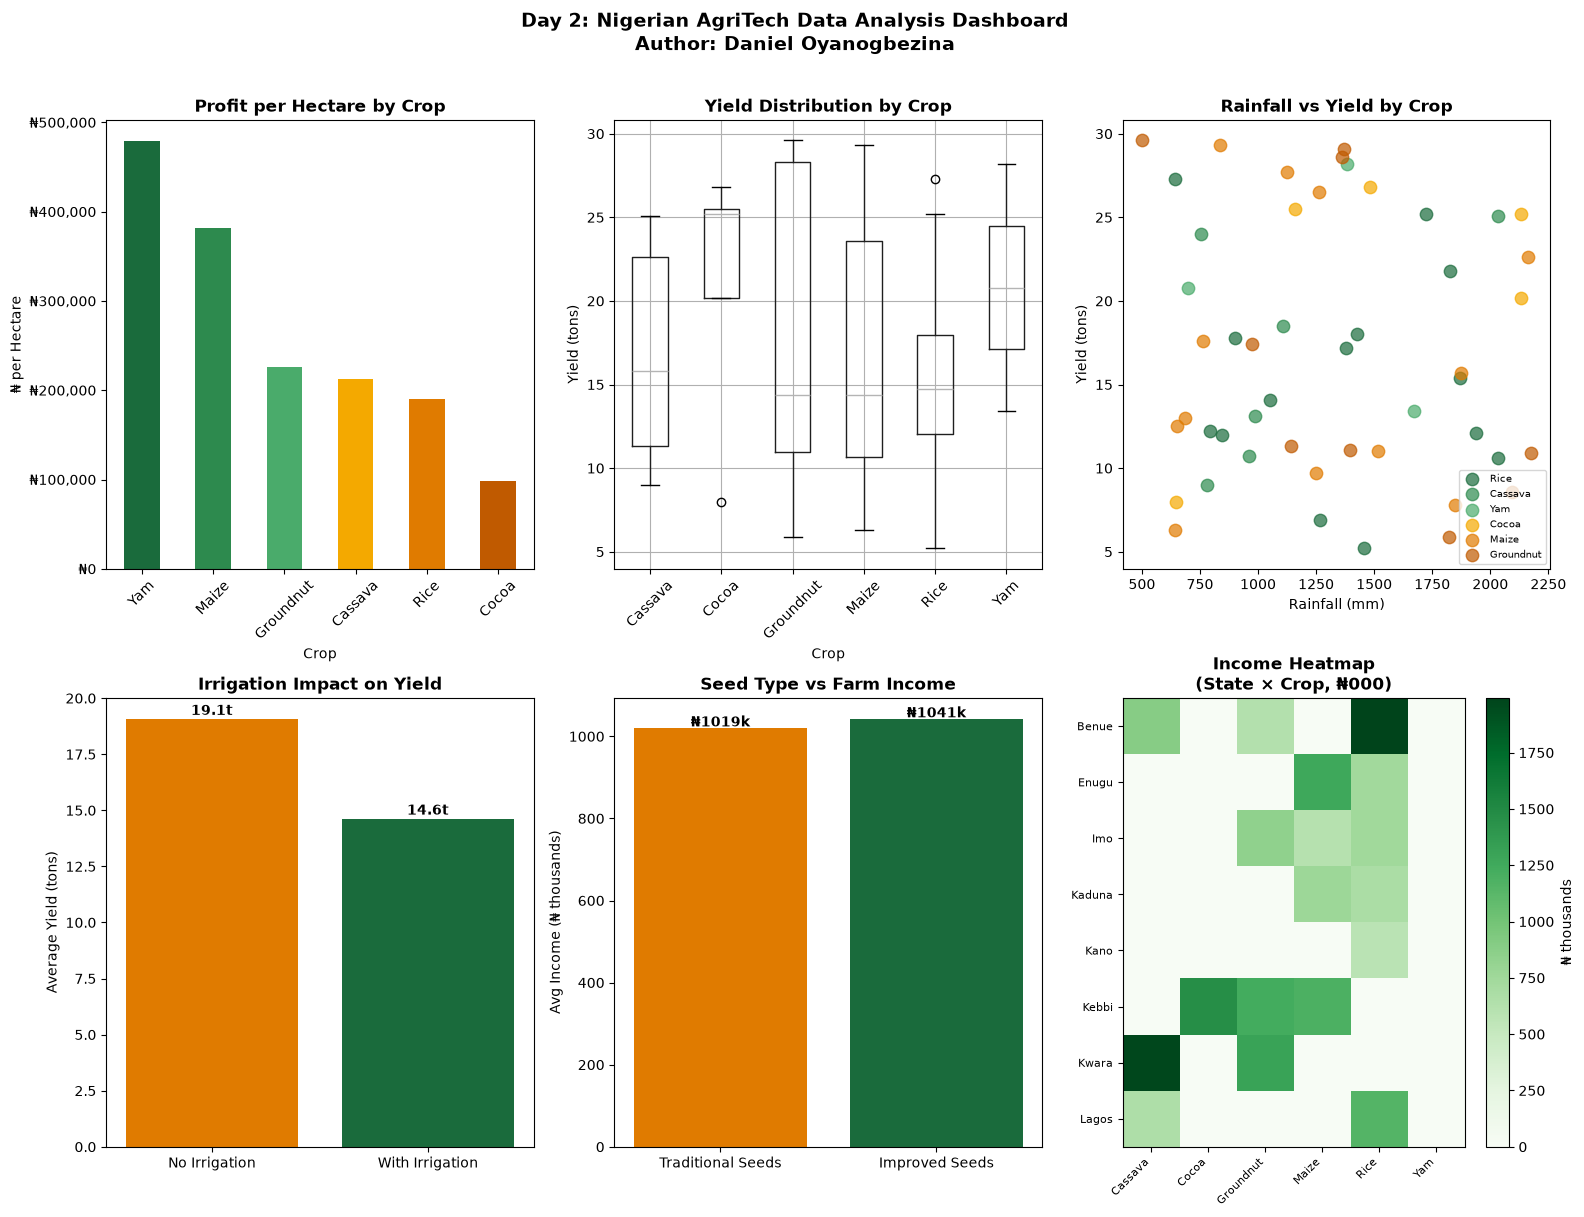

✅ Dashboard saved to docs/day02_advanced_analysis.png
📸 Screenshot this for your LinkedIn post!


In [15]:
# Cell 6 - Professional Charts

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 3, figure=fig)

# Color palette
colors = ['#1a6b3c', '#2d8a4e', '#4aab6b', '#f4a900', '#e07b00', '#c05a00']

# Chart 1: Crop profitability
ax1 = fig.add_subplot(gs[0, 0])
crop_profit.plot(kind='bar', ax=ax1, color=colors[:len(crop_profit)])
ax1.set_title('Profit per Hectare by Crop', fontweight='bold')
ax1.set_xlabel('Crop')
ax1.set_ylabel('₦ per Hectare')
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'₦{x:,.0f}')
)

# Chart 2: Yield distribution by crop
ax2 = fig.add_subplot(gs[0, 1])
df_clean.boxplot(column='yield_tons', by='crop', ax=ax2)
ax2.set_title('Yield Distribution by Crop', fontweight='bold')
ax2.set_xlabel('Crop')
ax2.set_ylabel('Yield (tons)')
plt.sca(ax2)
plt.xticks(rotation=45)

# Chart 3: Rainfall vs Yield scatter
ax3 = fig.add_subplot(gs[0, 2])
for i, crop in enumerate(df_clean['crop'].unique()):
    mask = df_clean['crop'] == crop
    ax3.scatter(
        df_clean[mask]['rainfall_mm'],
        df_clean[mask]['yield_tons'],
        label=crop, alpha=0.7, s=80,
        color=colors[i % len(colors)]
    )
ax3.set_title('Rainfall vs Yield by Crop', fontweight='bold')
ax3.set_xlabel('Rainfall (mm)')
ax3.set_ylabel('Yield (tons)')
ax3.legend(fontsize=7)

# Chart 4: Irrigation impact
ax4 = fig.add_subplot(gs[1, 0])
irr_data = df_clean.groupby('irrigation')['yield_tons'].mean()
bars = ax4.bar(
    ['No Irrigation', 'With Irrigation'],
    irr_data.values,
    color=['#e07b00', '#1a6b3c']
)
ax4.set_title('Irrigation Impact on Yield', fontweight='bold')
ax4.set_ylabel('Average Yield (tons)')
for bar, val in zip(bars, irr_data.values):
    ax4.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f'{val:.1f}t',
        ha='center', fontweight='bold'
    )

# Chart 5: Seeds impact
ax5 = fig.add_subplot(gs[1, 1])
seed_data = df_clean.groupby('improved_seeds')['income_naira'].mean() / 1000
bars2 = ax5.bar(
    ['Traditional Seeds', 'Improved Seeds'],
    seed_data.values,
    color=['#e07b00', '#1a6b3c']
)
ax5.set_title('Seed Type vs Farm Income', fontweight='bold')
ax5.set_ylabel('Avg Income (₦ thousands)')
for bar, val in zip(bars2, seed_data.values):
    ax5.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        f'₦{val:.0f}k',
        ha='center', fontweight='bold'
    )

# Chart 6: State income heatmap
ax6 = fig.add_subplot(gs[1, 2])
state_crop = df_clean.groupby(['state', 'crop'])['income_naira'].mean().unstack(fill_value=0)
state_crop_top = state_crop.head(8)
im = ax6.imshow(state_crop_top.values / 1000, cmap='Greens', aspect='auto')
ax6.set_xticks(range(len(state_crop_top.columns)))
ax6.set_xticklabels(state_crop_top.columns, rotation=45, ha='right', fontsize=8)
ax6.set_yticks(range(len(state_crop_top.index)))
ax6.set_yticklabels(state_crop_top.index, fontsize=8)
ax6.set_title('Income Heatmap\n(State × Crop, ₦000)', fontweight='bold')
plt.colorbar(im, ax=ax6, label='₦ thousands')

plt.suptitle(
    'Day 2: Nigerian AgriTech Data Analysis Dashboard\nAuthor: Daniel Oyanogbezina',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('docs/day02_advanced_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Dashboard saved to docs/day02_advanced_analysis.png")
print("📸 Screenshot this for your LinkedIn post!")

In [10]:
# Cell 7 - REAL Data from APIs

import requests
import json
import pandas as pd

print("🌍 Fetching REAL agricultural data...")
print("=" * 50)

# ── API 1: Real weather data for Nigerian farming states ──
# Open-Meteo is FREE, no API key needed
# Perfect for our learning journey

def get_farm_weather(city_name, lat, lon):
    """
    Fetch real weather data for a farming location
    Using Open-Meteo API (completely free, no signup)
    """
    url = "https://api.open-meteo.com/v1/forecast"

    params = {
        'latitude': lat,
        'longitude': lon,
        'daily': [
            'temperature_2m_max',
            'temperature_2m_min',
            'precipitation_sum',
            'windspeed_10m_max'
        ],
        'timezone': 'Africa/Lagos',
        'past_days': 7,      # Last 7 days
        'forecast_days': 7   # Next 7 days
    }

    response = requests.get(url, params=params, timeout=10)

    if response.status_code == 200:
        data = response.json()
        daily = data['daily']

        df = pd.DataFrame({
            'date': daily['time'],
            'max_temp_c': daily['temperature_2m_max'],
            'min_temp_c': daily['temperature_2m_min'],
            'rainfall_mm': daily['precipitation_sum'],
            'wind_speed': daily['windspeed_10m_max'],
            'city': city_name
        })

        return df
    else:
        print(f"  ⚠️  Could not fetch data for {city_name}")
        return None

# Key Nigerian farming locations with coordinates
locations = [
    ('Ibadan (Oyo)',    7.3775, 3.9470),
    ('Kano',           12.0022, 8.5920),
    ('Makurdi (Benue)', 7.7337, 8.5220),
    ('Enugu',           6.4584, 7.5464),
    ('Ilorin (Kwara)',  8.4966, 4.5421)
]

# Fetch data for each location
all_weather = []

for city, lat, lon in locations:
    print(f"  Fetching weather for {city}...")
    df = get_farm_weather(city, lat, lon)
    if df is not None:
        all_weather.append(df)
        print(f"  ✅ Got {len(df)} days of data for {city}")

# Combine all weather data
weather_df = pd.concat(all_weather, ignore_index=True)

print(f"\n✅ Total records fetched: {len(weather_df)}")
print("\nSample of REAL weather data:")
print(weather_df.head(10).to_string(index=False))

🌍 Fetching REAL agricultural data...
  Fetching weather for Ibadan (Oyo)...
  ✅ Got 14 days of data for Ibadan (Oyo)
  Fetching weather for Kano...
  ✅ Got 14 days of data for Kano
  Fetching weather for Makurdi (Benue)...
  ✅ Got 14 days of data for Makurdi (Benue)
  Fetching weather for Enugu...
  ✅ Got 14 days of data for Enugu
  Fetching weather for Ilorin (Kwara)...
  ✅ Got 14 days of data for Ilorin (Kwara)

✅ Total records fetched: 70

Sample of REAL weather data:
      date  max_temp_c  min_temp_c  rainfall_mm  wind_speed         city
2026-09-05        28.9        23.1          6.7         8.9 Ibadan (Oyo)
2026-09-06        28.0        22.7          6.7        10.8 Ibadan (Oyo)
2026-09-07        29.0        23.2          7.8         8.5 Ibadan (Oyo)
2026-09-08        28.4        23.5          3.4        10.6 Ibadan (Oyo)
2026-09-09        28.7        23.2          1.3        12.3 Ibadan (Oyo)
2026-09-10        28.2        23.3          6.5        11.2 Ibadan (Oyo)
2026-09-11   

In [11]:
# Cell 8 - Analyse the real weather data

print("🌦️  REAL WEATHER ANALYSIS FOR NIGERIAN FARMERS")
print("=" * 60)

# Average conditions by city
city_summary = weather_df.groupby('city').agg({
    'max_temp_c': 'mean',
    'min_temp_c': 'mean',
    'rainfall_mm': 'sum',
    'wind_speed': 'mean'
}).round(1)

city_summary.columns = [
    'Avg Max Temp (°C)',
    'Avg Min Temp (°C)',
    'Total Rainfall (mm)',
    'Avg Wind Speed'
]

print("\n📊 14-Day Weather Summary by Location:")
print(city_summary.to_string())

# Farming recommendations based on real data
print("\n\n🌱 AI FARMING RECOMMENDATIONS (Based on Real Data)")
print("=" * 60)

for city in weather_df['city'].unique():
    city_data = weather_df[weather_df['city'] == city]
    avg_rain = city_data['rainfall_mm'].sum()
    avg_temp = city_data['max_temp_c'].mean()

    print(f"\n📍 {city}:")
    print(f"   Temperature: {avg_temp:.1f}°C | Rainfall: {avg_rain:.1f}mm")

    # Simple rule-based recommendations
    # (Day 30+ we'll make these AI-powered)
    if avg_rain < 5:
        print("   ⚠️  Very dry - Irrigate crops if possible")
        print("   🌱 Best crops now: Drought-resistant varieties")
    elif avg_rain < 20:
        print("   ✅ Moderate rainfall - Good for maize, cassava")
        print("   💡 Monitor soil moisture daily")
    else:
        print("   🌧️  High rainfall - Watch for fungal diseases")
        print("   ✅ Good for rice cultivation")

    if avg_temp > 35:
        print("   🌡️  High heat stress - Water crops in evening")
    elif avg_temp < 20:
        print("   ❄️  Cool conditions - Delay planting sensitive crops")
    else:
        print("   🌤️  Good temperature range for most crops")
        

🌦️  REAL WEATHER ANALYSIS FOR NIGERIAN FARMERS

📊 14-Day Weather Summary by Location:
                 Avg Max Temp (°C)  Avg Min Temp (°C)  Total Rainfall (mm)  Avg Wind Speed
city                                                                                      
Enugu                         29.6               23.2                138.0            11.1
Ibadan (Oyo)                  28.8               23.2                111.4            10.9
Ilorin (Kwara)                29.9               23.0                 86.4            13.7
Kano                          32.4               22.9                 29.5            13.7
Makurdi (Benue)               30.9               23.9                 78.9            11.6


🌱 AI FARMING RECOMMENDATIONS (Based on Real Data)

📍 Ibadan (Oyo):
   Temperature: 28.8°C | Rainfall: 111.4mm
   🌧️  High rainfall - Watch for fungal diseases
   ✅ Good for rice cultivation
   🌤️  Good temperature range for most crops

📍 Kano:
   Temperature: 32.5°C | Rainfa

In [12]:
# Cell 9 - Save real data for future use

import os

# Create datasets folder structure
os.makedirs('datasets/weather', exist_ok=True)
os.makedirs('datasets/crops', exist_ok=True)

# Save weather data
weather_df.to_csv('datasets/weather/nigeria_weather_real.csv', index=False)
print("✅ Real weather data saved: datasets/weather/nigeria_weather_real.csv")

# Save cleaned farm data from earlier
df_clean.to_csv('datasets/crops/nigeria_farms_cleaned.csv', index=False)
print("✅ Farm data saved: datasets/crops/nigeria_farms_cleaned.csv")

# Quick verify
print(f"\n📁 Weather dataset: {len(weather_df)} rows × {len(weather_df.columns)} columns")
print(f"📁 Farm dataset: {len(df_clean)} rows × {len(df_clean.columns)} columns")
print("\nThese datasets will be used to train our AI model on Day 10+")

✅ Real weather data saved: datasets/weather/nigeria_weather_real.csv
✅ Farm data saved: datasets/crops/nigeria_farms_cleaned.csv

📁 Weather dataset: 70 rows × 6 columns
📁 Farm dataset: 50 rows × 13 columns

These datasets will be used to train our AI model on Day 10+


In [13]:
# Cell 10 - Professional data quality report

def data_quality_report(df, name):
    """
    Generate a professional data quality report
    This is what real data scientists do before any analysis
    """
    print(f"\n{'='*60}")
    print(f"DATA QUALITY REPORT: {name}")
    print(f"{'='*60}")

    # Basic info
    print(f"\n📐 Size: {df.shape[0]:,} rows × {df.shape[1]} columns")

    # Missing values
    missing = df.isnull().sum()
    if missing.sum() == 0:
        print("✅ No missing values found")
    else:
        print(f"\n❓ Missing Values:")
        for col in missing[missing > 0].index:
            pct = missing[col] / len(df) * 100
            print(f"   {col:<20}: {missing[col]} ({pct:.1f}%)")

    # Duplicates
    dupes = df.duplicated().sum()
    if dupes == 0:
        print("✅ No duplicate rows found")
    else:
        print(f"⚠️  Duplicate rows: {dupes}")

    # Numeric column ranges
    print("\n📊 Numeric Column Ranges:")
    numeric = df.select_dtypes(include=[np.number])
    for col in numeric.columns:
        print(f"   {col:<25}: min={numeric[col].min():.1f}, "
              f"max={numeric[col].max():.1f}, "
              f"mean={numeric[col].mean():.1f}")

    print(f"\n{'='*60}")
    return True

# Run quality reports on our datasets
data_quality_report(df_clean, "Nigeria Farm Data")
data_quality_report(weather_df, "Nigeria Weather Data")


DATA QUALITY REPORT: Nigeria Farm Data

📐 Size: 50 rows × 13 columns

❓ Missing Values:
   rainfall_mm         : 1 (2.0%)
   soil_ph             : 1 (2.0%)
   fertilizer_kg       : 1 (2.0%)
✅ No duplicate rows found

📊 Numeric Column Ranges:
   farm_id                  : min=1.0, max=50.0, mean=25.5
   farm_size_ha             : min=0.6, max=14.8, mean=7.3
   yield_tons               : min=5.2, max=29.6, mean=17.3
   rainfall_mm              : min=501.0, max=2175.0, mean=1317.0
   soil_ph                  : min=5.0, max=7.5, mean=6.4
   fertilizer_kg            : min=5.0, max=193.0, mean=99.0
   year                     : min=2022.0, max=2024.0, mean=2022.9
   income_naira             : min=251934.0, max=1992662.0, mean=1028135.2
   income_per_hectare       : min=23131.6, max=2271546.7, mean=253958.5


DATA QUALITY REPORT: Nigeria Weather Data

📐 Size: 70 rows × 6 columns
✅ No missing values found
✅ No duplicate rows found

📊 Numeric Column Ranges:
   max_temp_c               : min=28

True

In [14]:
# Cell 11 - Day 2 Reflection

print("""
╔══════════════════════════════════════════════════════════╗
║           DAY 2 REFLECTION - AgriTech AI Journey        ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  What I mastered today:                                  ║
║  ✅ Advanced Pandas operations                          ║
║  ✅ Data cleaning (missing values, strategies)          ║
║  ✅ Correlation analysis                                ║
║  ✅ Group-by aggregations                               ║
║  ✅ Fetched REAL weather data from live API             ║
║  ✅ Built 6-chart professional dashboard                ║
║  ✅ Generated automated farming recommendations         ║
║  ✅ Saved datasets for future AI training               ║
║                                                          ║
║  Key Insight Today:                                      ║
║  Real data is messy. Cleaning it is a skill.            ║
║  The API gave us live Nigerian weather data in          ║
║  seconds — that same data costs consultants             ║
║  thousands to compile manually.                         ║
║                                                          ║
║  Tomorrow (Day 3):                                       ║
║  → Introduction to Machine Learning                     ║
║  → Build first predictive model                         ║
║  → Predict crop yield from weather + soil data          ║
║                                                          ║
║  Day 2 of 365 Complete! 🌱                              ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║           DAY 2 REFLECTION - AgriTech AI Journey        ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  What I mastered today:                                  ║
║  ✅ Advanced Pandas operations                          ║
║  ✅ Data cleaning (missing values, strategies)          ║
║  ✅ Correlation analysis                                ║
║  ✅ Group-by aggregations                               ║
║  ✅ Fetched REAL weather data from live API             ║
║  ✅ Built 6-chart professional dashboard                ║
║  ✅ Generated automated farming recommendations         ║
║  ✅ Saved datasets for future AI training               ║
║                                                          ║
║  Key Insight Today:                                      ║
║  Real data is messy. Cleaning it is a skill.            ║
║  The API gave us live Nigerian weather 